# Imports and setup

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import os
import warnings
import logging
import gc

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

warnings.filterwarnings('ignore')

# ===== FORCE CPU ONLY - DISABLE GPU =====
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Verify GPU is disabled
print("GPU Available:", len(tf.config.list_physical_devices('GPU')))
print("CPU Devices:", tf.config.list_physical_devices('CPU'))
print("\n✅ Running on CPU only mode\n")


GPU Available: 0
CPU Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

✅ Running on CPU only mode



In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import gc
import tensorflow as tf

# Clear memory at start
tf.keras.backend.clear_session()
gc.collect()

# --- dataset path configuration ---
import os

# assume you've run ``python ../dataset.py`` before to download
# the kaggle dataset into ./datasets
datasets_root = os.path.join(os.getcwd(), "../datasets")

# try to locate the actual downloaded folder
candidates = [d for d in os.listdir(datasets_root) if "chest_xray" in d]
if not candidates:
    raise FileNotFoundError(
        "Could not find a dataset directory containing 'chest_xray' inside ../datasets. "
        "Run python ../dataset.py or adjust the path manually."
    )

base_dir = os.path.join(datasets_root, candidates[0], "chest_xray")

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

print("using data from:", base_dir)


datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2, 
    rotation_range=5,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)


train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(160, 160),
    batch_size=2,
    class_mode='binary',
    subset='training', 
    shuffle=True
)


val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(160, 160),
    batch_size=2,
    class_mode='binary',
    subset='validation', 
    shuffle=False
)


test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(160, 160),
    batch_size=2,
    class_mode='binary',
    shuffle=False
)

print(f" Training images: {train_gen.samples}")
print(f" Validation images: {val_gen.samples}")
print(f" Testing images: {test_gen.samples}")


using data from: /home/FedoroX/Documents/capstone_project/notebooks/../datasets/chest_xray/chest_xray
Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
 Training images: 4173
 Validation images: 1043
 Testing images: 624


# Loading the datasets

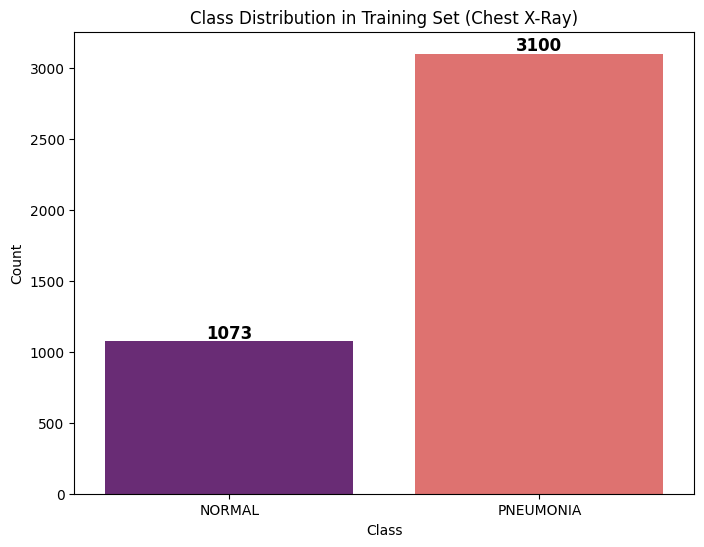

In [10]:

labels = train_gen.classes
class_names = list(train_gen.class_indices.keys())
counts = [np.sum(labels == i) for i in range(len(class_names))]


df_plot = pd.DataFrame({'Class': class_names, 'Count': counts})


plt.figure(figsize=(8, 6))
sns.barplot(x='Class', y='Count', data=df_plot, palette='magma')


for i, count in enumerate(counts):
    plt.text(i, count + 20, str(count), ha='center', fontsize=12, fontweight='bold')

plt.title('Class Distribution in Training Set (Chest X-Ray)')
plt.show()

# Computing Class Weights

In [11]:
from sklearn.utils.class_weight import compute_class_weight

y_train = train_gen.classes

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)


class_weight_dict = {i: weights[i] for i in range(len(weights))}

print("Computed Class Weights:")
for i, name in enumerate(class_names):
    print(f"   - {name}: {class_weight_dict[i]:.4f}")


Computed Class Weights:
   - NORMAL: 1.9445
   - PNEUMONIA: 0.6731


# MobileNetV2 model setup

In [12]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(160, 160, 3))


base_model.trainable = False 


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x) 
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(1, activation='sigmoid')(x) 

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])


In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,299,009 (8.77 MB)

 Trainable params: 41,025 (160.25 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Callbacks

In [14]:
import os

# For Jupyter notebooks: construct models directory relative to current directory
# Notebooks are typically in ./notebooks/, so go up one level to project root
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)
models_dir = os.path.join(project_root, 'models')

# Alternative if notebook is not in ./notebooks/:
# models_dir = os.path.join(os.getcwd(), 'models')

os.makedirs(models_dir, exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
    ModelCheckpoint(os.path.join(models_dir, 'medical_pneumonia_model.keras'), save_best_only=True)
]

print(f"Current working directory: {os.getcwd()}")
print(f"Models will be saved to: {models_dir}")


Current working directory: /home/FedoroX/Documents/capstone_project/notebooks
Models will be saved to: /home/FedoroX/Documents/capstone_project/models


In [15]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    verbose=1,
    callbacks=callbacks
)


Epoch 1/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.8797 - loss: 0.2649 - val_accuracy: 0.9588 - val_loss: 0.1261 - learning_rate: 1.0000e-04
Epoch 2/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - accuracy: 0.9343 - loss: 0.1633 - val_accuracy: 0.9444 - val_loss: 0.1397 - learning_rate: 1.0000e-04
Epoch 3/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 45s 22ms/step - accuracy: 0.9451 - loss: 0.1472 - val_accuracy: 0.9540 - val_loss: 0.1086 - learning_rate: 1.0000e-04
Epoch 4/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 45s 22ms/step - accuracy: 0.9449 - loss: 0.1394 - val_accuracy: 0.9607 - val_loss: 0.1062 - learning_rate: 1.0000e-04
Epoch 5/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.9473 - loss: 0.1328 - val_accuracy: 0.9578 - val_loss: 0.1075 - learning_rate: 1.0000e-04


# Confusion matrix

312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
              precision    recall  f1-score   support

      Normal       0.84      0.91      0.87       234
   Pneumonia       0.94      0.89      0.92       390

    accuracy                           0.90       624
   macro avg       0.89      0.90      0.89       624
weighted avg       0.90      0.90      0.90       624



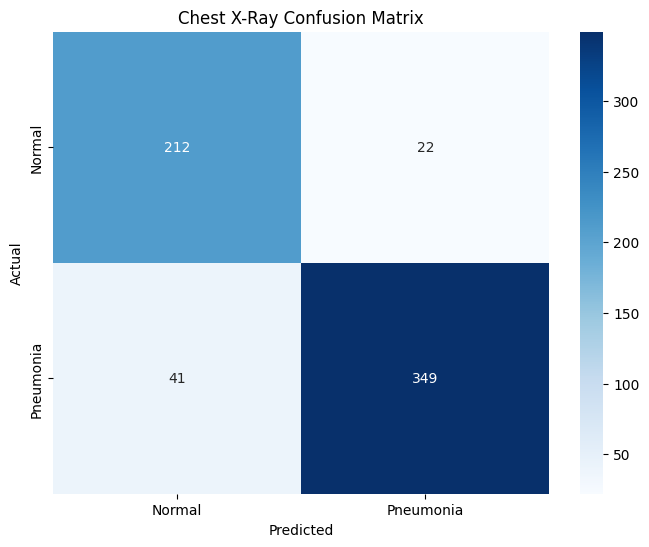

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use the test_gen generator we created earlier for consistent evaluation
y_true = test_gen.classes
predictions = model.predict(test_gen, verbose=1)
y_pred = (predictions > 0.5).astype(int).flatten()

print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Chest X-Ray Confusion Matrix')
plt.show()


In [17]:
model.save(os.path.join(models_dir, 'medical_pneumonia_model_final.keras'))
print(f"Model saved to: {os.path.join(models_dir, 'medical_pneumonia_model_final.keras')}")


Model saved to: /home/FedoroX/Documents/capstone_project/models/medical_pneumonia_model_final.keras


In [18]:
from IPython.display import FileLink
FileLink(r'medical_pneumonia_model_final.keras')

/home/FedoroX/Documents/capstone_project/notebooks/medical_pneumonia_model_final.keras

# Cascade Model

In [19]:
import os
import pandas as pd
import numpy as np

def prepare_cascade_data(base_path):
    normal_dir = os.path.join(base_path, 'NORMAL')
    pneumo_dir = os.path.join(base_path, 'PNEUMONIA')
    
    
    normal_files = [os.path.join(normal_dir, f) for f in os.listdir(normal_dir) if not f.startswith('.')]
    pneumo_files = [os.path.join(pneumo_dir, f) for f in os.listdir(pneumo_dir) if not f.startswith('.')]
    
    np.random.shuffle(pneumo_files)
    chunk_size = len(normal_files)
    cascades = []
    
    num_cascades = int(np.ceil(len(pneumo_files) / chunk_size))
    
    print(f"Total Normal: {len(normal_files)}")
    print(f"Total Pneumonia: {len(pneumo_files)}")
    print(f"Creating {num_cascades} balanced cascades...")

    for i in range(num_cascades):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, len(pneumo_files))
        
        
        current_pneumo_chunk = pneumo_files[start:end]
        
       
        chunk_files = normal_files + current_pneumo_chunk
        
       
        chunk_labels = ['NORMAL'] * len(normal_files) + ['PNEUMONIA'] * len(current_pneumo_chunk)
        
        # إنشاء الـ DataFrame
        df = pd.DataFrame({
            'filepath': chunk_files, 
            'label': chunk_labels
        })
        
        cascades.append(df.sample(frac=1).reset_index(drop=True))
        
    return cascades

# التشغيل الآن
train_path = train_dir
cascade_dfs = prepare_cascade_data(train_path)

for i, df in enumerate(cascade_dfs):
    print(f"Cascade {i+1}: {len(df)} images ({df['label'].value_counts().to_dict()})")

Total Normal: 1341
Total Pneumonia: 3875
Creating 3 balanced cascades...
Cascade 1: 2682 images ({'PNEUMONIA': 1341, 'NORMAL': 1341})
Cascade 2: 2682 images ({'NORMAL': 1341, 'PNEUMONIA': 1341})
Cascade 3: 2534 images ({'NORMAL': 1341, 'PNEUMONIA': 1193})


In [20]:
train_path = train_dir
cascade_dfs = prepare_cascade_data(train_path)

print(f"Created 3 Balanced Cascades. Each with {len(cascade_dfs[0])} images.")

Total Normal: 1341
Total Pneumonia: 3875
Creating 3 balanced cascades...
Created 3 Balanced Cascades. Each with 2682 images.


# Cascade Model Export

In [21]:
import tensorflow as tf
import gc

base_lr = 1e-4

all_histories = []

for i, df in enumerate(cascade_dfs):
    print(f"\nStarting Cascade Stage {i+1}/{len(cascade_dfs)}")
    
    # Clear memory between cascade stages
    gc.collect()
    tf.keras.backend.clear_session()
    
    current_lr = base_lr / (10**i) 
    model.optimizer.learning_rate = current_lr
    print(f"Learning Rate set to: {current_lr}")

    temp_train_gen = datagen.flow_from_dataframe(
        df,
        x_col='filepath',
        y_col='label',
        target_size=(160, 160),
        batch_size=2,
        class_mode='binary',
        shuffle=True 
    )
    

    history = model.fit(
        temp_train_gen,
        epochs=5, 
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1
    )
    
    all_histories.append(history.history)
    print(f"Finished Stage {i+1}")



Starting Cascade Stage 1/3
Learning Rate set to: 0.0001
Found 2682 validated image filenames belonging to 2 classes.
Epoch 1/5
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.9333 - loss: 0.1590 - val_accuracy: 0.9415 - val_loss: 0.1418 - learning_rate: 1.0000e-04
Epoch 2/5
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.9403 - loss: 0.1557 - val_accuracy: 0.9684 - val_loss: 0.0888 - learning_rate: 1.0000e-04
Epoch 3/5
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.9474 - loss: 0.1396 - val_accuracy: 0.9578 - val_loss: 0.1094 - learning_rate: 1.0000e-04
Epoch 4/5
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.9448 - loss: 0.1526 - val_accuracy: 0.9501 - val_loss: 0.1215 - learning_rate: 1.0000e-04
Epoch 5/5
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.9444 - loss: 0.1444 - val_accuracy: 0.9549 - val_loss: 0.1108 - learning_rate: 1.0000e-04
Finished Stage 1

Starting Cascade Stage 2/3
Learning Rate set to: 1e-05
Found 2682 val

312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


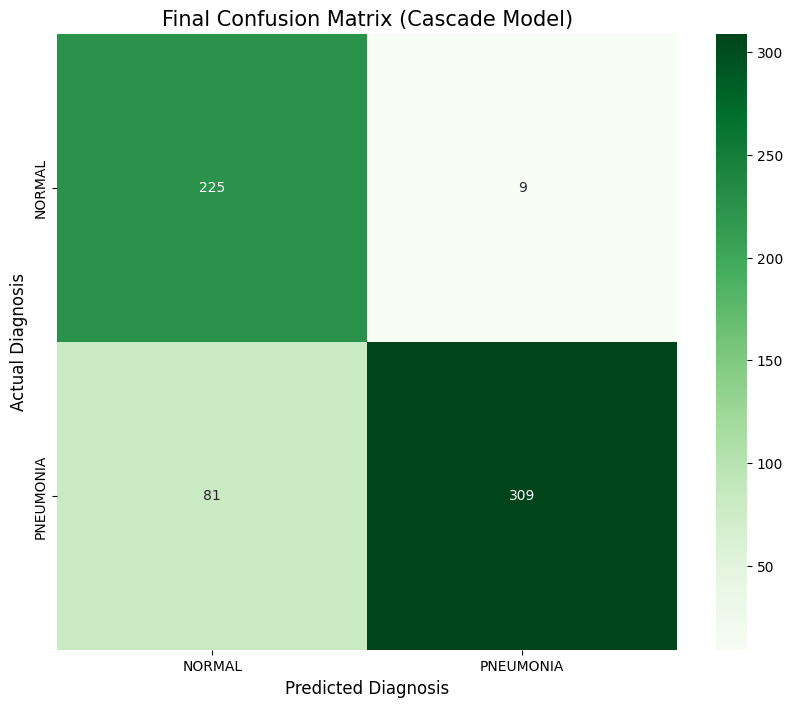


 Detailed Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.74      0.96      0.83       234
   PNEUMONIA       0.97      0.79      0.87       390

    accuracy                           0.86       624
   macro avg       0.85      0.88      0.85       624
weighted avg       0.88      0.86      0.86       624


🩺 Model Sensitivity (Ability to detect Pneumonia): 79.23%


In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


test_gen.reset()
predictions = model.predict(test_gen, verbose=1)

y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys()) # ['NORMAL', 'PNEUMONIA']

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_labels, 
            yticklabels=class_labels)

plt.title('Final Confusion Matrix (Cascade Model)', fontsize=15)
plt.xlabel('Predicted Diagnosis', fontsize=12)
plt.ylabel('Actual Diagnosis', fontsize=12)
plt.show()

print("\n Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

sensitivity = cm[1,1] / (cm[1,1] + cm[1,0])
print(f"\n🩺 Model Sensitivity (Ability to detect Pneumonia): {sensitivity*100:.2f}%")

In [23]:
model.save(os.path.join(models_dir, 'chest_cascade_model_final.keras'))
print(f"Cascade model saved to: {os.path.join(models_dir, 'chest_cascade_model_final.keras')}")


Cascade model saved to: /home/FedoroX/Documents/capstone_project/models/chest_cascade_model_final.keras


In [24]:
FileLink(r'chest_cascade_model_final.keras')

/home/FedoroX/Documents/capstone_project/notebooks/chest_cascade_model_final.keras

In [25]:
import json
import os

class_names = sorted(os.listdir(train_dir))

with open(os.path.join(models_dir, 'chest_classes.json'), 'w') as f:
    json.dump(class_names, f)

print(f"Classes saved to: {os.path.join(models_dir, 'chest_classes.json')}")
print(f"Saved classes: {class_names}")


Classes saved to: /home/FedoroX/Documents/capstone_project/models/chest_classes.json
Saved classes: ['.DS_Store', 'NORMAL', 'PNEUMONIA']
